In [2]:
#----------------------------------------------------------------------------------
# Libraries 

import numpy as np
import matplotlib.pyplot as plt
from tank_geometry import tank_geometry
from tank_mechanical_sizing import tank_mechanical_sizing
import scipy.integrate
import math
from scipy.integrate import simpson
from rocketpy import (
    CylindricalTank,
    Environment,
    Flight,
    Fluid,
    Function,
    LiquidMotor,
    MassBasedTank,
    Rocket,
    UllageBasedTank,
    MassFlowRateBasedTank,  
)
from rocketpy.plots.compare import CompareFlights

# ---------------------------------------------
# The main objective of this Jupyter Notebook script is, first and foremost, to design a rocket geometry based on various input parameters provided by the user. 
# This allows for approximation of the rocket's shape and an initial aerodynamic study, who must be realize on a different software (RASAero II).
# Once the corresponding aerodynamic coefficients are determined, the script uses the RocketPy library to simulate the rocket's behavior under specified environmental conditions,
# including the calculation of the resulting forces. Among the many outputs generated, the most relevant include the Mach number, apogee trajectory, and Δv of the system.  
# ---------------------------------------------

In [3]:
# --------------------------------
# INPUT DATA 
# --------------------------------
# Basic Parameters to compute a bi-liquid rocket with separated tanks system and helium pressurant tank regarding the following parameters :

# Parameters:
# - Payloads and Bays Masses
# - TORGOS Engine Geometry and Performance Parameters
# - Tanks Dimensional Parameters
# - Rocket Fuselage Size and Design Parameters
# - Bays Length Parameters
# - Fins Design Parameters
# --------------------------------

# General Requirements
MIS = {}

#---------Mass------------
# System Mass
MIS['Mu'] = 1             # Target Payload mass [kg]
MIS['MRecovery'] = 0      # Estimated Internal Components Mass [kg] for the Recovery  
MIS['MAvionics'] = 5.5    # Estimated Internal Components Mass [kg] for Avionics Bay  
MIS['MUpper_Bay'] = 6     # Estimated Internal Components Mass [kg] for Upper Bay (No Helium Tank)
MIS['MInter_Tanks'] = 0.5 # Estimated Internal Components Mass [kg] between oxydizer and fuel tank
MIS['MLower_Bay'] = 3     # Estimated Internal Components Mass [kg] for Lower Bay 
MIS['MEngine'] = 6        # Estimated Engine Mass [kg]
MIS['Mfins'] = 0.47       # Estimated Fin Mass (1 Unit) [kg]

#---------TORGOS------------
# TORGOS Geometry Parameters
TORGOS_l_c = 217.8           # Chamber length (including the catalytic zone) [mm]
TORGOS_l_cv = 86             # Convergent length [mm]
TORGOS_l_dv = 61             # Divergent length [mm]
TORGOS_D_c = 107             # Chamber diameter [mm]
TORGOS_D_t = 47.5            # Throat diameter [mm]
TORGOS_D_e = 82              # Exit diameter [mm]
TORGOS_l_t = TORGOS_l_c+TORGOS_l_cv+TORGOS_l_dv  # Total length [mm]

# TORGOS Performance
MIS['ISP'] = 220      # ISP [s]
MIS['g0'] =  9.81     # Earth Acceleration cosntant [m/s^2]
MIS['Ve'] =  2160.50  # TORGOS ejection speed [m/s]
MIS['Mass_Flow_Rate_TORGOS'] = 1.62 # Mass Flow Rate TORGOS [kg/s]

#---------Tanks---------------
p_C3H8 = 40  # Pressure [bar] // Propane Tank
p_H2O2 = 40  # Pressure [bar] // Peroxide Tank
p_He = 350   # Pressure [bar] // Helium Tank
# Propellant Volume inside Tanks [L]
MIS['H2O2_vol'] = 40          # Volume Peroxide [L]
MIS['gas_He_vol'] = 14.4      # Volume Pressurized Helium [L]

# Mix Ratio 
mix_ratio = 7.5 

#---------Geometry------------
# Diameters [mm]
R_D_ext = 230                # External Rocket Diameter 
R_D_tanks = 230              # Propellant Tanks External Diameter
R_D_tank_He = 210            # Helium Tank External Diameter
# Fuselage Propeties
t_body  = 2                  # Cylindrical Fuselage Thickness [mm] 
t_fairing = 2                # Nosecone Thickness [mm]
rho_body = 1.55e-6           # Density Rocket Body Fuselage Material [kg/mm³] (Carbon-Fiber Composite)
rho_avionics = 2.15e-6       # Density Avionics Fuselage Material [kg/mm³] (Glass-Fiber Composite)
rho_fairing = 1.55e-6        # Density Nosecone Fuselage Material [kg/mm³] (Carbon-Fiber Composite)
BT_l = 150                   # Boat tail length [mm]
BT_angle = 4                 # Boat tail Convergance angle [°]
# Metallic Connectors
w1 = 5                       # Number of Flanges
w2 = 0.250                   # Estimated Weight of One Flange
#---------Bays------------
# Internal Bays Length [mm]
avionics_length = 350                      # Avionics Length [mm]
recovery_length = 0                        # Recovery Length [mm]  
pressurization_bay_umbilical_length = 350  # Length of Umbilical and Fluidic Lines (Upper Bay) [mm]
IT_ub = 50                                 # Space between the propane tank and the nitrogen tank [mm]
lower_bay_length = 364                     # Lower Bay Length [mm] 

#--------Fins-------------
n=4                                        # Numbers of fins
Root_Chord=0.364                           # Root Chord [m]                  
Tip_Chord=0.190                           # Tip Chord [m]
Span= 0.2286                               # Span [m]
Sweep_Length = 0.240                       # Sweep Distance [m]
Cant_angle=0                               # Cant Angle [m]
#--------Outputs----------
OUT = {}

In [4]:
# -------------------------------
# Nosecone
# -------------------------------

# Von Karman Nose Length = 5 * External Diameter
NC_l_nc = 5*R_D_ext

# Longitudinal nose axis
NC_x_nc = np.linspace(0,NC_l_nc,1000)

# Theta Angulus regarding von Karman shape
NC_theta = np.arccos(1-2*NC_x_nc/NC_l_nc)

# Von Karman nose profile in Y
NC_y_nc = R_D_ext/(2*np.sqrt(np.pi))*np.sqrt(NC_theta-np.sin(2*NC_theta)/2)


In [5]:
# ------------------------------
# Tank Geometry - Hydrogen Peroxyde (H2O2) 
# ------------------------------
# Gaz Mass
OUT['H2O2_dens'] = 1275.52     # Peroxide Density [kg/m3]
OUT['H2O2_mass'] = MIS['H2O2_vol']*1e-3*OUT['H2O2_dens'] # [kg]

# Tank geometry
TANK_H2O2 = tank_geometry(MIS['H2O2_vol'],R_D_tanks)
# Tank mechanical sizing
TANK_H2O2 = tank_mechanical_sizing(MIS['H2O2_vol'],R_D_tanks,p_H2O2,1,2,TANK_H2O2)

print(f'Wet Mass Peroxide (H2O2) : {OUT['H2O2_mass']:.2f} kg')

Wet Mass Peroxide (H2O2) : 51.02 kg


In [6]:
# ------------------------------
# Tank Geometry - Propane (C3H8)
# ------------------------------
# Gaz Mass
OUT['C3H8_dens'] = 506.948    # Propane  Density [kg/m3]
OUT['C3H8_mass'] = OUT['H2O2_mass'] / mix_ratio # [kg]
OUT['C3H8_vol'] =  OUT['C3H8_mass'] / (OUT['C3H8_dens']*1e-3)# [L]

# Tank geometry
TANK_C3H8 = tank_geometry(OUT['C3H8_vol'],R_D_tanks)
# Tank mechanical sizing
TANK_C3H8 = tank_mechanical_sizing(OUT['C3H8_vol'],R_D_tanks,p_C3H8,1,2,TANK_C3H8)

print(f'Wet Mass Propane (C3H8) : {OUT['C3H8_mass']:.2f} kg')

Wet Mass Propane (C3H8) : 6.80 kg


In [7]:
# ------------------------------
# Pressurant Tank Geometry - Helium (He)
# ------------------------------
# Gaz Mass
OUT['gas_He_dens'] = 49.114   # Helium Density [kg/m3] 
OUT['gas_He_mass'] =  MIS['gas_He_vol']*1e-3*OUT['gas_He_dens'] # [kg]
# Tank geometry
TANK_He = tank_geometry(MIS['gas_He_vol'],R_D_tank_He)
# Tank mechanical sizing
TANK_He = tank_mechanical_sizing(MIS['gas_He_vol'],R_D_tank_He,p_He,2,1,TANK_He)

print(f'Wet Mass Helium (He) : {OUT['gas_He_mass']:.2f} kg')

Wet Mass Helium (He) : 0.71 kg


In [8]:
# ------------------------------
# Boat tail
# ------------------------------
BT_angle_rad = np.radians(BT_angle)
# Low Surface boat tail diameter 
BT_D = R_D_ext - np.tan(BT_angle_rad)*BT_l*2

print(f'Rear boat tail diameter : {BT_D:.2f} mm')

Rear boat tail diameter : 209.02 mm


In [9]:
# ------------------------------
# Coordinates and total values
# ------------------------------

COORD_tank_He = NC_l_nc + recovery_length + avionics_length + 10 # [mm] -- A separation of 10 mm has been applied between the avionics bay and pressurization bay
COORD_tank_C3H8 = COORD_tank_He+ TANK_He.get('l_t') + pressurization_bay_umbilical_length + 10 # [mm] -- A separation of 10 mm has been applied y
COORD_tank_H2O2 = COORD_tank_C3H8 + TANK_C3H8.get('l_t')  + IT_ub # [mm]
COORD_torgos = COORD_tank_H2O2+TANK_H2O2.get('l_t') + lower_bay_length + 10 # [mm] -- A separation of 10 mm has been applied between the engine bay and the propellant tanks bay
COORD_boattail = COORD_torgos+TORGOS_l_t-BT_l # [mm]

R_l_t = COORD_boattail+BT_l # [mm]
R_LD = R_l_t/R_D_ext        # Ratio [Rocket Length/Rocket Diameter]

In [10]:
#----------------------------------------------
# Fuselage Mass Calculation 
#----------------------------------------------
# Inner Fairing profile 
R_D_int = R_D_ext - 2*t_fairing     # Inner Fairing Radius [mm]
NC_l_nc_int = 5*R_D_int             # Inner Fairing Length [mm]
NC_x_nc_int = np.linspace(0,NC_l_nc_int,1000)   # Construction x axis geometry
NC_y_nc_int = R_D_int/(2*np.sqrt(np.pi))*np.sqrt(NC_theta-np.sin(2*NC_theta)/2) # Construction y axis geometry

# -------------------------------
# Volumes Fairing (revolve around x-axis)
# -------------------------------
V_ext = np.pi * simpson(NC_y_nc**2, NC_x_nc)           # Inner Fairing Volume + Fairing Volume [mm^3]
V_int = np.pi * simpson(NC_y_nc_int**2, NC_x_nc_int)   # Inner Fairing Volume [mm^3]
V_wall = V_ext - V_int                                 # Fairing Volume [mm^3]

# Fuselage Mass 
OUT['M_Fairing'] =  V_wall*rho_fairing # Mass of the Fairing Fuselage [kg]
OUT['M_Main_Rocket_Body'] = 2*np.pi*(R_D_ext/2-2*t_body)*t_body*(R_l_t-BT_l-(NC_l_nc+avionics_length))*rho_body + w1*w2  # Mass Carbon Fuselage + Flanges [kg]
OUT['M_Avionics_Fuselage'] = 2*np.pi*(R_D_ext/2-2*t_body)*t_body*avionics_length*rho_avionics # Mass Avionics Fuselage [kg]
OUT['M_Boatail'] = BT_l*(np.pi/3)*((BT_D/2)**2+(R_D_ext/2)**2+(BT_D/2)*(R_D_ext)/2)*2.81*1e-6 # Mass Boat tail [kg]
OUT['M_Rocket_Body'] =OUT['M_Main_Rocket_Body'] + OUT['M_Avionics_Fuselage']+ OUT['M_Boatail']  # Mass of the Main Body Fuselage [kg]
OUT['M_Fuselage'] = OUT['M_Fairing'] + OUT['M_Rocket_Body']       # Total Fuselage Mass [kg]

#----------------------------------------------
# Δv Calculation 
#---------------------------------------------- 
OUT['PROP_mass'] = OUT['H2O2_mass'] + OUT['C3H8_mass']      # Propellant Mass [kg] 
OUT['Mf'] = OUT['M_Fuselage'] + MIS['Mu'] + MIS['MRecovery'] + MIS['MAvionics'] + TANK_He['W_t'] + MIS['MInter_Tanks'] + TANK_C3H8['W_t'] + TANK_H2O2['W_t'] +  n*MIS['Mfins'] +  MIS['MUpper_Bay']  + MIS['MLower_Bay'] + MIS['MEngine'] # Dry Mass [kg]
OUT['Mi'] = OUT['Mf'] + OUT['gas_He_mass'] + OUT['PROP_mass']  # Wet Mass [kg]
OUT['Δv'] = MIS['ISP']*MIS['g0']*math.log(OUT['Mi']/OUT['Mf']) # [m/s]

#----------------------------------------------
# Output Visualization 
#---------------------------------------------- 
print(f'---- Mass Balance ----')
print(f'Dry Mass : {OUT['Mf']:.2f} kg')
print(f'Wet Mass : {OUT['Mi']:.2f} kg')
print(f'Estimated Burn Time : {OUT['PROP_mass'] /MIS['Mass_Flow_Rate_TORGOS'] :.2f} s')
print(f'Dry Mass/Full Mass : {OUT['Mf']/OUT['Mi']:.2f}')
print(f'Theoretical Δv : {OUT['Δv']:.2f} s')

---- Mass Balance ----
Dry Mass : 66.38 kg
Wet Mass : 124.91 kg
Estimated Burn Time : 35.69 s
Dry Mass/Full Mass : 0.53
Theoretical Δv : 1364.45 s


In [11]:
#-------------------------------
# Bays Connectors Coordinates -- Visual Plot
#-------------------------------
# Fairing
x_fairing = NC_l_nc  
y_min_fairing = -R_D_ext/2  
y_max_fairing = R_D_ext/2  
# Recovery
x_recovery = x_fairing + recovery_length  
y_min_recovery = -R_D_ext/2  
y_max_recovery = R_D_ext/2  
# Avionics
x_avionics = x_recovery + avionics_length  
y_min_avionics = -R_D_ext/2  
y_max_avionics= R_D_ext/2 
# Pressurization Bay 
x_pressurization_bay = COORD_tank_He + TANK_He.get('l_t') + pressurization_bay_umbilical_length  
y_min_pressurization_bay = -R_D_ext/2 
y_max_pressurization_bay = R_D_ext/2  
# Propellant Bay
x_propellant = COORD_tank_H2O2  + TANK_H2O2.get('l_t') + 10  
y_min_propellant = -R_D_ext/2  
y_max_propellant = R_D_ext/2  
# Lower Bay
x_lower_bay =  x_propellant + lower_bay_length  
y_min_lower_bay = -R_D_ext/2  
y_max_lower_bay = R_D_ext/2  

In [12]:
# ------------------------------
# Rocket Center of Gravity (CG) before Launch - Wet Configuration
# ------------------------------

# Fairing Bay Mass considering an internal payload
M_Fairing_Bay = OUT['M_Fairing'] + MIS['Mu']
# Thin Walled Fairing Cone CG (Fairing Local Referential) - [mm]
Cg_fairing_local = (2/3)*x_fairing
# Recovery Bay CG (Recovery Local Referential) - [mm]                        
Cg_recovery_local = (x_recovery-x_fairing)/2                   
# Avionics Bay CG (Avionics Local Referential) - [mm]
Cg_avionics_local = (x_avionics-x_recovery)/2   
# Pressurization Bay Mass before launch 
M_Pressurization_Bay = TANK_He['W_t'] + OUT['gas_He_mass'] + MIS['MUpper_Bay']
# Pressurization Bay CG before launch ( Pressurant Bay Local Referential) - [mm]
Cg_pressurization_bay_local = (TANK_He['W_t']*(TANK_He['l_t']/2) + OUT['gas_He_mass']*(TANK_He['l_t']/2) + MIS['MUpper_Bay']*(TANK_He['l_t']+(pressurization_bay_umbilical_length+10)/2))/M_Pressurization_Bay
# Tank Bay Cg before launch (Tanks Bay Local Referential) - [mm]
a =  TANK_C3H8['W_t']*(10+TANK_C3H8['l_t']/2)
b =  OUT['C3H8_mass']*(10+TANK_C3H8['l_t']/2)
c =  TANK_H2O2['W_t']*(10+TANK_C3H8['l_t']+IT_ub+TANK_H2O2['l_t']/2)
d =  OUT['H2O2_mass']*(10+TANK_C3H8['l_t']+IT_ub+TANK_H2O2['l_t']/2)
e =  MIS['MInter_Tanks']*(10+TANK_C3H8['l_t'] + IT_ub/2)
M_Propellant_Tank = TANK_C3H8['W_t'] + OUT['C3H8_mass'] + TANK_H2O2['W_t'] + OUT['H2O2_mass'] + MIS['MInter_Tanks']
Cg_tanks_bay_local = (a+b+c+d+e)/M_Propellant_Tank
# Lower Bay CG (Lower Bay Local Referential) - [mm]
Cg_lower_bay_local = (x_lower_bay - x_propellant)/2
# Engine Bay CG (Engine Bay Local Referential) - [mm]
Cg_engine_bay_local = 167
# Fins CG (Fins Local Referential) - (ATTENTION!!! UNIT [m]) - (To Verify)
Cg_fins_local_z = 0.62*(2/3)*(Root_Chord-Tip_Chord)+0.38*(Root_Chord-Tip_Chord+Tip_Chord/2) # z-axis (roll axis)
Cg_fins_local_y = 0.62*(Span/3)+0.38*(Span/2) # y-axis (pitch axis)
# Fuselage Body CG (Fuselage Body Local Referential) - [mm] - (Fairing Fuselage is included in Fairing Bay Mass)
Cg_body_fuselage = (OUT['M_Main_Rocket_Body']*(R_l_t-BT_l-x_avionics)/2 + OUT['M_Avionics_Fuselage']*(x_avionics-x_recovery)/2 + OUT['M_Boatail']*(COORD_boattail-x_avionics+BT_l/2))/OUT['M_Rocket_Body']
# Rocket Cone CG (Rocket Referential) - [mm]
Cg_cone = Cg_fairing_local
# Rocket Cylander CG (Rocket Referential) - [mm]
aa = (Cg_cone*M_Fairing_Bay + MIS['MRecovery']*(x_fairing+Cg_recovery_local) + MIS['MAvionics']*(x_recovery+Cg_avionics_local) + OUT['M_Rocket_Body']*(x_fairing + Cg_body_fuselage) + n*MIS['Mfins']*(x_lower_bay + Cg_fins_local_z*1e3))
M_Cg_without_motor = MIS['MRecovery']+ MIS['MAvionics'] + OUT['M_Rocket_Body'] + n*MIS['Mfins'] + M_Fairing_Bay
Cg_without_motor = aa/M_Cg_without_motor
Cg_cylinder_tanks = (M_Pressurization_Bay*(x_avionics+Cg_pressurization_bay_local) + M_Propellant_Tank*(x_pressurization_bay + Cg_tanks_bay_local) + MIS['MLower_Bay']*(x_propellant + Cg_lower_bay_local) + MIS['MEngine']*(x_lower_bay+Cg_engine_bay_local))/(OUT['Mi']- M_Cg_without_motor)
# Rocket CG (Rocket Referential) - [mm]
Cg = (Cg_cylinder_tanks*(OUT['Mi']- M_Cg_without_motor) + Cg_without_motor*M_Cg_without_motor)/OUT['Mi']
#----------------------------------------------
# Output Visualization 
#---------------------------------------------- 
print(f'Global Cg location before lauch (Wet Mass): {Cg:.2f} mm')
bb = (OUT['Mi']- M_Cg_without_motor) - (M_Pressurization_Bay+M_Propellant_Tank+MIS['MEngine']+MIS['MLower_Bay'])
print(f'bb : {bb:.2f} kg')
print(f'Cg without motor : {Cg_without_motor:.2f} mm')
print(f'Cg motor section : {Cg_cylinder_tanks:.2f} mm')


Global Cg location before lauch (Wet Mass): 3093.94 mm
bb : 0.00 kg
Cg without motor : 3021.81 mm
Cg motor section : 3121.89 mm


In [13]:
# ------------------------------
# Rocket Center of Gravity (CG) after burn-out - Dry Configuration (No Helium , Peroxide or Propane inside Tanks)
# ------------------------------
# Pressurization Bay Mass before launch 
M_Pressurization_Bay_dry = TANK_He['W_t'] + MIS['MUpper_Bay']
# Pressurization Bay CG before launch (Local Referential)
Cg_pressurization_bay_local_dry = (TANK_He['W_t']*(TANK_He['l_t']/2) + MIS['MUpper_Bay']*(TANK_He['l_t']+(pressurization_bay_umbilical_length+10)/2))/M_Pressurization_Bay_dry
# Tank Bay Cg before launch (Local Referential)
f =  TANK_C3H8['W_t']*(10+TANK_C3H8['l_t']/2)
g =  TANK_H2O2['W_t']*(10+TANK_C3H8['l_t']+IT_ub+TANK_H2O2['l_t']/2)
h =  MIS['MInter_Tanks']*(10+TANK_C3H8['l_t'] + IT_ub/2)
M_Propellant_Tank_dry = TANK_C3H8['W_t'] + TANK_H2O2['W_t']  + MIS['MInter_Tanks']
Cg_tanks_bay_local_dry = (f+g+h)/M_Propellant_Tank_dry
# Rocket Cylander CG (Rocket Referential)
Cg_cylinder_tanks_dry= (M_Pressurization_Bay_dry*(x_avionics+Cg_pressurization_bay_local_dry) + M_Propellant_Tank_dry*(x_pressurization_bay +Cg_tanks_bay_local_dry) + MIS['MLower_Bay']*(x_propellant + Cg_lower_bay_local)  + (MIS['MEngine'])*(x_lower_bay+Cg_engine_bay_local))/(OUT['Mf']- M_Cg_without_motor)
# Rocket CG (Rocket Referential) 
Cg_dry = (Cg_cylinder_tanks_dry*(OUT['Mf']- M_Cg_without_motor) + Cg_without_motor*M_Cg_without_motor)/OUT['Mf']
#----------------------------------------------
# Output Visualization 
#---------------------------------------------- 
print(f'Global Cg location after burn-out (Dry Mass): {Cg_dry:.2f} mm')
cc = (OUT['Mf']- M_Cg_without_motor) - (M_Pressurization_Bay_dry+M_Propellant_Tank_dry+MIS['MEngine']+MIS['MLower_Bay'])
print(f'cc : {cc:.2f} kg')

Global Cg location after burn-out (Dry Mass): 2985.83 mm
cc : 0.00 kg


In [14]:
# -----------------------------------------
# Fonctions to Calculate different Moment of Inertia Tensor for different Geometrical Bodies
# -----------------------------------------
def inertia_tensor_cone(M, R):
    """Inertia tensor at center of mass of solid cone (aligned along z-axis)"""
    I_xx = I_yy = (3/20) * M * R**2
    I_zz = (3/10) * M * R**2
    return np.diag([I_xx, I_yy, I_zz])

def inertia_tensor_cylinder(M, R, h):
    """Inertia tensor at center of mass of solid cylinder (aligned along z-axis)"""
    I_xx = I_yy = (1/12) * M * (3 * R**2 + h**2)
    I_zz = (1/2) * M * R**2
    return np.diag([I_xx, I_yy, I_zz])

def inertia_tensor_thick_hollow_cylinder(M, R_in, R_out, h):
    """
    Inertia tensor at center of mass of a thick-walled hollow cylinder (aligned along z-axis).
    
    Parameters:
    - M: total mass
    - R_in: inner radius
    - R_out: outer radius
    - h: height of the cylinder
    
    Returns:
    - 3x3 numpy array (inertia tensor)
    """
    I_xx = I_yy = (1/12) * M * (3 * (R_out**2 + R_in**2) + h**2)
    I_zz = (1/2) * M * (R_out**2 + R_in**2)
    return np.diag([I_xx, I_yy, I_zz]) 

def trapezoidal_fin_inertia(m, b, cr, ct):
    """
    Inertia tensor at the center of mass of a trapezoidal fin (chord along the z-axis)

    m : mass [kg]
    b : span [m]
    cr : root chord [m]
    ct : tip chord [m]

    Retourne : tenseur d'inertie 3x3 au centre de masse
    """
    I_xx = (m * b * (cr**2 + 4 * cr * ct + ct**2)) / (36 * (cr + ct))
    I_yy = (m / 48) * (cr + ct)**2
    I_zz = I_xx + I_yy

    return np.diag([I_xx, I_yy, I_zz])

def inertia_clipped_delta_fin(c_r, c_t, s, m):
    """
    Computes the inertia tensor of a clipped delta fin (trapezoid) in rocket body axes.

    Rocket body frame:
    - z: along rocket (chord direction)
    - x: fin span (perpendicular to rocket axis)
    - y: fin thickness (small, neglected)

    Parameters:
    - c_r: root chord length (meters)
    - c_t: tip chord length (meters)
    - s: span of the fin (meters)
    - m: mass of the fin (kg)

    Returns:
    - inertia_tensor: 3x3 numpy array (kg·m^2)
    """
    # Original axis-based moments:
    I_span = (m * s**2) / 12  # was I_xx
    num = c_r**3 + c_r**2 * c_t + c_r * c_t**2 + c_t**3
    den = c_r + c_t
    I_chord = (m / 12) * (num / den)  # was I_yy
    I_out_of_plane = I_span + I_chord  # was I_zz

    # Reassign to rocket body axes:
    # x: span, y: thickness, z: chord
    I_xx = I_span
    I_yy = I_out_of_plane  # rotation about axis normal to fin plane
    I_zz = I_chord

    inertia_tensor = np.diag([I_xx, I_yy, I_zz])
    return inertia_tensor

def inertia_tensor_isosceles_pyramid_xy_base(M, b, h, t):
    """
    Moment of inertia tensor of an isosceles triangular pyramid 
    with the base in the xy plane:
    - b : triangle base along the x-axis
    - h : triangle height along the y-axis
    - t : pyramid height along the z-axis

    Output :
    - inertia moment tensor 3x3 (kg·m²)
    """
    I_xx = (3/20) * M * (h**2 + t**2)
    I_yy = (3/20) * M * (b**2 + t**2)
    I_zz = (3/20) * M * (h**2 + b**2)

    return np.diag([I_xx, I_yy, I_zz])

def inertia_tensor_rectangular_prism(M, L, W, H):
    """
    Moment of inertia tensor of a rectangular homogenous solid prism
    
    Parameters :
    - M : mass [kg]
    - L : length (x-axis) [m]
    - W : width (y-axis) [m]
    - H : height (z-axis) [m]

    Output :
    - inertia tensor 3x3 (kg·m²)
    """
    I_xx = (1/12) * M * (W**2 + H**2)
    I_yy = (1/12) * M * (L**2 + H**2)
    I_zz = (1/12) * M * (L**2 + W**2)

    return np.diag([I_xx, I_yy, I_zz])

def shift_inertia_tensor(I_com, M, d_vec):
    """Shift inertia tensor using the parallel axis theorem"""
    d2 = np.dot(d_vec, d_vec)
    I3 = np.eye(3)
    ddT = np.outer(d_vec, d_vec)
    return I_com + M * (d2 * I3 - ddT)

In [15]:
# Inertia 
# --------------------------------------------
# Compute Dry Inertia Tensor - Motor System (Local Referential)
# --------------------------------------------
# 1. Inertia at each component local Center Of Mass (COMs) (Helium Tank/Propane Tank/Peroxide Tank/IT_b/Upper Umbilical/Lower Bay/Engine Bay)
Cylinder_helium_tank_length = TANK_He["l_t"]*1e-3                             # [m]
Cylinder_propane_tank_length = TANK_C3H8['l_t']*1e-3                          # [m]
Cylinder_peroxide_tank_length = TANK_H2O2['l_t']*1e-3                         # [m]
Cylinder_IT_ub_length = IT_ub*1e-3                                            # [m]
Cylinder_upper_bay_length = (pressurization_bay_umbilical_length + 10)*1e-3   # [m]
Cylinder_lower_bay_length =  lower_bay_length*1e-3                            # [m]
Cylinder_engine_bay_length = (R_l_t - x_lower_bay)*1e-3                       # [m]

I_helium_tank_dry_com = inertia_tensor_cylinder(TANK_He["W_t"], (R_D_tank_He/2)*1e-3, Cylinder_helium_tank_length)       # [kg·m²]
I_propane_tank_dry_com = inertia_tensor_cylinder(TANK_C3H8['W_t'], (R_D_tanks/2)*1e-3, Cylinder_propane_tank_length)     # [kg·m²]
I_peroxide_tank_dry_com = inertia_tensor_cylinder(TANK_H2O2['W_t'], (R_D_tanks/2)*1e-3, Cylinder_peroxide_tank_length)   # [kg·m²]
I_IT_ub_com = inertia_tensor_cylinder(MIS['MInter_Tanks'], (R_D_ext/2)*1e-3, Cylinder_IT_ub_length )                     # [kg·m²]
I_umbilical_com = inertia_tensor_cylinder(MIS['MUpper_Bay'],(R_D_ext/2)*1e-3, Cylinder_upper_bay_length )                # [kg·m²]
I_lower_bay_com = inertia_tensor_cylinder(MIS['MLower_Bay'],(R_D_ext/2)*1e-3, Cylinder_lower_bay_length )                # [kg·m²]
I_engine_bay_com = inertia_tensor_cylinder(MIS['MEngine'],(R_D_ext/2)*1e-3, Cylinder_engine_bay_length)                  # [kg·m²]

# 2. Shift vectors from component COMs to Motor Referential (only z component) # [m]
Cg_helium_motor = (COORD_tank_He + TANK_He['l_t']/2 - x_avionics)*1e-3                                                   # [m]
Cg_propane_motor = (COORD_tank_C3H8 + TANK_C3H8['l_t']/2 - x_avionics)*1e-3                                              # [m]
Cg_peroxide_motor = (COORD_tank_H2O2 + TANK_H2O2['l_t']/2 - x_avionics)*1e-3                                             # [m]
Cg_IT_ub_motor = (COORD_tank_C3H8 + TANK_C3H8['l_t'] + IT_ub/2 - x_avionics)*1e-3                                        # [m]
Cg_umbilical_motor = (COORD_tank_He + TANK_He['l_t'] + (pressurization_bay_umbilical_length + 10)/2 - x_avionics)*1e-3   # [m]
Cg_lower_bay_motor = (x_propellant +  lower_bay_length/2 - x_avionics)*1e-3                                              # [m]
Cg_engine_bay_motor = ((R_l_t - x_lower_bay) - x_avionics)*1e-3                                                          # [m]
# Distance between the local center of mass of each section wityh the center of mass of the Motor System
d_1 = np.array([0, 0, Cg_helium_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3])     # [m]
d_2 = np.array([0, 0, Cg_propane_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3])    # [m]
d_3 = np.array([0, 0, Cg_peroxide_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3])   # [m]
d_4 = np.array([0, 0, Cg_IT_ub_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3])      # [m]
d_5 = np.array([0, 0, Cg_umbilical_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3])  # [m]
d_6 = np.array([0, 0, Cg_lower_bay_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3])  # [m]
d_7 = np.array([0, 0, Cg_engine_bay_motor - (Cg_cylinder_tanks_dry-x_avionics)*1e-3]) # [m]

# 3. Shifted tensors to global COM
I_d1_global = shift_inertia_tensor(I_helium_tank_dry_com, TANK_He["W_t"], d_1)       # [kg·m²]
I_d2_global = shift_inertia_tensor(I_propane_tank_dry_com, TANK_C3H8['W_t'], d_2)    # [kg·m²]
I_d3_global = shift_inertia_tensor(I_peroxide_tank_dry_com, TANK_H2O2['W_t'], d_3)   # [kg·m²]
I_d4_global = shift_inertia_tensor(I_IT_ub_com, MIS['MInter_Tanks'], d_4)            # [kg·m²]
I_d5_global = shift_inertia_tensor(I_umbilical_com, MIS['MUpper_Bay'], d_5)          # [kg·m²]
I_d6_global = shift_inertia_tensor(I_lower_bay_com, MIS['MLower_Bay'], d_6)          # [kg·m²]
I_d7_global = shift_inertia_tensor(I_engine_bay_com, MIS['MEngine'], d_7)            # [kg·m²]

# 4. Total inertia tensor
I_total = I_d1_global + I_d2_global + I_d2_global + I_d3_global + I_d4_global + I_d5_global + I_d6_global + I_d7_global # [kg·m²]

# --------------------------------------------
# Output
# --------------------------------------------
np.set_printoptions(precision=2, suppress=True)

print("\nTotal Inertia Tensor for Motor Section (Motor Section Referential (kg·m²)):")
print(I_total)


Total Inertia Tensor for Motor Section (Motor Section Referential (kg·m²)):
[[60.2   0.    0.  ]
 [ 0.   60.2   0.  ]
 [ 0.    0.    0.21]]


In [16]:
# Inertia 
# --------------------------------------------
# Compute Dry Inertia Tensor - Without Motor Configuration (Rocket Referential)
# --------------------------------------------
# 1. Inertia at component COMs
Cone_fairing_length = NC_l_nc*1e-3                 # [m]
Cylinder_recovery_length = recovery_length*1e-3    # [m]
Cylinder_avionics_length = avionics_length*1e-3    # [m]
Cylinder_body_bay_length = (R_l_t-x_fairing)*1e-3  # [m]
Cylinder_fins_length = Root_Chord

I_fairing_com = inertia_tensor_cone(M_Fairing_Bay, (R_D_ext/2)*1e-3)                                                                                 # [kg·m²]
I_recovery_com = inertia_tensor_cylinder(MIS['MRecovery'],(R_D_ext/2)*1e-3, Cylinder_recovery_length)                                                # [kg·m²]
I_avionics_com = inertia_tensor_cylinder(MIS['MAvionics'],(R_D_ext/2)*1e-3, Cylinder_avionics_length)                                                # [kg·m²]
I_body_fuselage_com = inertia_tensor_thick_hollow_cylinder(OUT['M_Rocket_Body'],(R_D_ext/2-t_body)*1e-3,(R_D_ext/2)*1e-3, Cylinder_body_bay_length)  # [kg·m²]
I_fins_tring = inertia_tensor_isosceles_pyramid_xy_base(0.62*MIS['Mfins'],0.02,Span,Root_Chord)                                                      # [kg·m²]
I_fins_square = inertia_tensor_rectangular_prism(0.38*MIS['Mfins'],0.02,Span,Root_Chord)                                                             # [kg·m²]

# Shift vectors from fins subsections to fins referential
d_fin_1 = np.array([0, Span/3 - Cg_fins_local_y, (2/3)*(Root_Chord-Tip_Chord) - Cg_fins_local_z])        # [m]
d_fin_2 = np.array([0, (Root_Chord-Tip_Chord)+Tip_Chord/2 - Cg_fins_local_y, Span/2 - Cg_fins_local_z])  # [m]
I_fin_1 = shift_inertia_tensor(I_fins_tring, 0.62*MIS['Mfins'], d_fin_1)                                 # [m]
I_fin_2 = shift_inertia_tensor(I_fins_square, 0.38*MIS['Mfins'], d_fin_2)                                # [m]
I_fins_com = I_fin_1 + I_fin_2
# 2. Shift vectors from component COMs to Without Motor Configuration (only z component)
d_8 = np.array([0, 0, (Cg_cone - Cg_without_motor)*1e-3])                           # [m]
d_9 = np.array([0, 0, (x_fairing + Cg_recovery_local - Cg_without_motor)*1e-3])     # [m]
d_10 = np.array([0, 0, (x_recovery + Cg_avionics_local - Cg_without_motor)*1e-3])   # [m]
d_11 = np.array([0, 0, (x_fairing + Cg_body_fuselage - Cg_without_motor)*1e-3])     # [m]
if n==3:
 d_12 = np.array([0, Cg_fins_local_y + (R_D_ext/2)*1e-3, x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3])
 d_13 = np.array([-math.sin(math.degrees(30))*(Cg_fins_local_y + (R_D_ext/2)*1e-3), -math.sin(math.degrees(60))*(Cg_fins_local_y + (R_D_ext/2)*1e-3), x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3]) # [m]
 d_14 = np.array([-math.sin(math.degrees(30)*(Cg_fins_local_y + (R_D_ext/2)*1e-3)),  math.sin(math.degrees(60))*(Cg_fins_local_y + (R_D_ext/2)*1e-3), x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3]) # [m]

if n==4:
 d_12 = np.array([Cg_fins_local_y + (R_D_ext/2)*1e-3, 0, x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3])    # [m]
 d_13 = np.array([0, -(Cg_fins_local_y + (R_D_ext/2)*1e-3), x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3]) # [m]
 d_14 = np.array([-(Cg_fins_local_y + (R_D_ext/2)*1e-3), 0, x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3]) # [m]
 d_15 = np.array([0, Cg_fins_local_y + (R_D_ext/2)*1e-3, x_lower_bay*1e-3 + Cg_fins_local_z - Cg_without_motor*1e-3])    # [m]

# 3. Shifted tensors to Without Motor Configuration
I_d8_global = shift_inertia_tensor(I_fairing_com, M_Fairing_Bay, d_8)                 # [kg·m²]
I_d9_global = shift_inertia_tensor(I_recovery_com, MIS['MRecovery'], d_9)             # [kg·m²]
I_d10_global = shift_inertia_tensor(I_avionics_com, MIS['MAvionics'], d_10)           # [kg·m²]
I_d11_global = shift_inertia_tensor(I_body_fuselage_com, OUT['M_Rocket_Body'], d_11)  # [kg·m²]
if n==3:
  I_d12_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_12)                 # [kg·m²]
  I_d13_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_13)                 # [kg·m²]
  I_d14_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_14)                 # [kg·m²]
if n==4:
  I_d12_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_12)                 # [kg·m²]
  I_d13_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_13)                 # [kg·m²]
  I_d14_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_14)                 # [kg·m²]
  I_d15_global = shift_inertia_tensor(I_fins_com, MIS['Mfins'], d_15)                 # [kg·m²]

# 4. Total inertia tensor
if n==3:
 I_total_without_motor = I_d8_global + I_d9_global + I_d10_global + I_d11_global + I_d12_global + I_d13_global + I_d14_global                 # [kg·m²]
if n==4:
 I_total_without_motor = I_d8_global + I_d9_global + I_d10_global + I_d11_global + I_d12_global + I_d13_global + I_d14_global + I_d15_global  # [kg·m²]
print("Total Inertia Tensor for Without-Motor Section (Rocket Referential (kg·m²)):")
print(I_total_without_motor)
 

Total Inertia Tensor for Without-Motor Section (Rocket Referential (kg·m²)):
[[65.82  0.    0.  ]
 [ 0.   65.78  0.01]
 [ 0.    0.01  0.48]]


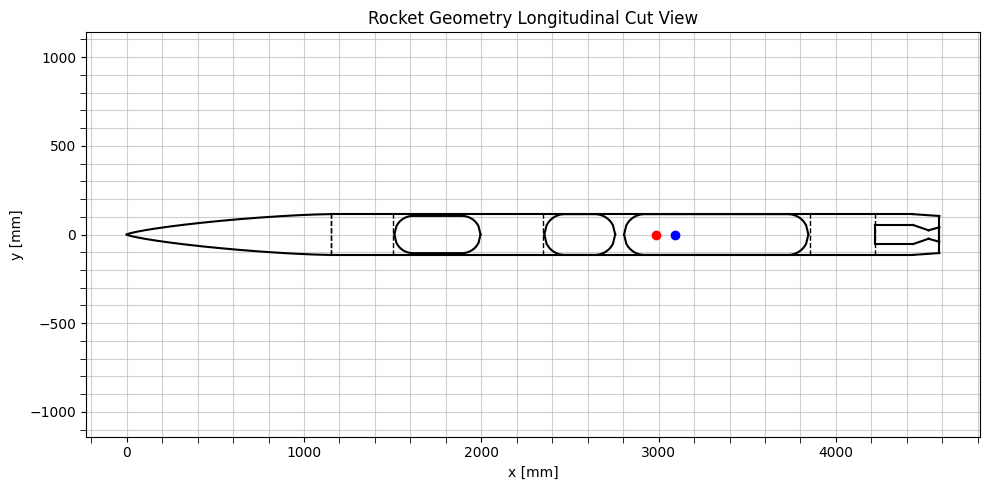

-----Geometry Parameters - RASAero II-----
Payload Mass: 1 kg
Diameter Nosecone : 230 mm --- 9.0551 in
Length Nosecone : 1150 mm --- 45.2756 in
Avionics Bay Length: 350 mm --- 13.7795 1n 
Pressurization Bay Length: 845.75 mm--- 33.2973 in
Tank Bay Length : 1509.07 mm --- 59.4121 in
Lower Bay Length : 364 mm --- 14.3307 in
Upper Shell Length : 214.80 mm --- 8.4567 in
Boat tail Length: 150 mm --- 5.9055 in
Boat tail Rear Diameter: 209.02195641694686 mm --- 8.2292 in
Rocket Length: 4583.62 mm --- 180.4574 in
Cg before launch : 3093.94 mm --- 121.8088 in
Cg dry: 2985.83 mm --- 117.5524 in 
Number of fins : 4
Root Chord : 364.0 mm --- 14.330709 in
Tip Chord : 190.0 mm --- 7.4803 in
Span : 228.6 mm --- 9.0000 in
Cant Angle : 0.00 deg
Sweep Distance :240.00 mm --- 9.4488 in
Peroxide Mass : 51.02 kg
Propane Mass : 6.80 kg
He Mass : 0.71 kg
Oxidizer and Fuel Mass : 57.82 kg


In [17]:
# ------------------------------
# Plot figure
# ------------------------------

plt.figure(figsize=(10, 5))
plt.axis('equal')  
plt.grid(True, which='both', linestyle='-', alpha=0.6)
plt.minorticks_on() 
plt.tick_params(which='minor', length=4)

# Von Kármán nosecone
plt.plot(NC_x_nc,  NC_y_nc,  'k')  
plt.plot(NC_x_nc, -NC_y_nc,  'k')  

# --- Peroxyde Tank H2O2 ---
plt.plot(COORD_tank_H2O2 + TANK_H2O2.get('x'),  TANK_H2O2.get('y'), 'k')
plt.plot(COORD_tank_H2O2 + TANK_H2O2.get('x'), -TANK_H2O2.get('y'),  'k')

# --- Propane Tank C3H8 ---
plt.plot(COORD_tank_C3H8 + TANK_C3H8.get('x'),  TANK_C3H8.get('y'),  'k')
plt.plot(COORD_tank_C3H8 + TANK_C3H8.get('x'), -TANK_C3H8.get('y'),  'k')

# --- Helium Tank He ---
plt.plot(COORD_tank_He + TANK_He.get('x'),  TANK_He.get('y'),  'k')
plt.plot(COORD_tank_He + TANK_He.get('x'), -TANK_He.get('y'),  'k')

# === TORGOS  Engine ===
# Combustion Chamber
plt.plot([COORD_torgos, COORD_torgos + TORGOS_l_c],
         [TORGOS_D_c / 2, TORGOS_D_c / 2], 'k')
plt.plot([COORD_torgos, COORD_torgos + TORGOS_l_c],
         [-TORGOS_D_c / 2, -TORGOS_D_c / 2], 'k')

# Convergent
plt.plot([COORD_torgos + TORGOS_l_c, COORD_torgos + TORGOS_l_c + TORGOS_l_cv],
         [TORGOS_D_c / 2, TORGOS_D_t / 2], 'k')
plt.plot([COORD_torgos + TORGOS_l_c, COORD_torgos + TORGOS_l_c + TORGOS_l_cv],
         [-TORGOS_D_c / 2, -TORGOS_D_t / 2], 'k')

# Divergent
plt.plot([COORD_torgos + TORGOS_l_c + TORGOS_l_cv, COORD_torgos + TORGOS_l_t],
         [TORGOS_D_t / 2, TORGOS_D_e / 2], 'k')
plt.plot([COORD_torgos + TORGOS_l_c + TORGOS_l_cv, COORD_torgos + TORGOS_l_t],
         [-TORGOS_D_t / 2, -TORGOS_D_e / 2], 'k')

# Vertical Walls
plt.plot([COORD_torgos, COORD_torgos],
         [-TORGOS_D_c / 2, TORGOS_D_c / 2], 'k')
plt.plot([COORD_torgos + TORGOS_l_t, COORD_torgos + TORGOS_l_t],
         [-TORGOS_D_e / 2, TORGOS_D_e / 2], 'k')


# --- Cylindrical Section of the rocket body ---
plt.plot(
    [NC_l_nc, COORD_boattail],
    [R_D_ext / 2, R_D_ext / 2],
    'k'
)
plt.plot(
    [NC_l_nc, COORD_boattail],
    [-R_D_ext / 2, -R_D_ext / 2],
    'k'
)

# === Boat Tail ===
plt.plot([COORD_boattail, COORD_boattail + BT_l],
         [R_D_ext / 2, BT_D / 2], 'k')
plt.plot([COORD_boattail, COORD_boattail + BT_l],
         [-R_D_ext / 2, -BT_D  / 2], 'k')
plt.plot([COORD_boattail + BT_l, COORD_boattail + BT_l],
         [-BT_D  / 2, BT_D  / 2], 'k')

# Plot Bays Delimiatation
plt.plot([x_fairing, x_fairing], [y_min_fairing, y_max_fairing], color='black', linestyle='--', linewidth=1)
plt.plot([x_recovery, x_recovery], [y_min_recovery, y_max_recovery], color='black', linestyle='--', linewidth=1)
plt.plot([x_avionics, x_avionics], [y_min_avionics, y_max_avionics], color='black', linestyle='--', linewidth=1)
plt.plot([x_pressurization_bay, x_pressurization_bay], [y_min_pressurization_bay, y_max_pressurization_bay], color='black', linestyle='--', linewidth=1)
plt.plot([x_propellant, x_propellant], [y_min_propellant, y_max_propellant], color='black', linestyle='--', linewidth=1)
plt.plot([x_lower_bay, x_lower_bay], [y_min_lower_bay, y_max_lower_bay], color='black', linestyle='--', linewidth=1)

# Plot Cg
plt.plot(Cg, 0, 'bo')
plt.plot(Cg_dry, 0, 'ro')

# Titles
plt.title('Rocket Geometry Longitudinal Cut View')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.tight_layout()
plt.show()

print('-----Geometry Parameters - RASAero II-----')
print(f'Payload Mass: {MIS['Mu']} kg')
print(f'Diameter Nosecone : {R_D_ext} mm --- {R_D_ext*0.0393700787:.4f} in')
print(f'Length Nosecone : {NC_l_nc} mm --- {NC_l_nc*0.0393700787:.4f} in')
if avionics_length != 0:
    print(f'Avionics Bay Length: {avionics_length} mm --- {0.0393700787*avionics_length:.4f} 1n ')
if recovery_length != 0:
    print(f'Recovery Bay Length: {recovery_length} mm --- {0.0393700787*recovery_length:.4f} in')
print(f'Pressurization Bay Length: {TANK_He.get('l_t') + pressurization_bay_umbilical_length +10:.2f} mm--- {0.0393700787*(TANK_He.get('l_t') + pressurization_bay_umbilical_length+10):.4f} in')
print(f'Tank Bay Length : {x_propellant - x_pressurization_bay:.2f} mm --- {0.0393700787*(x_propellant - x_pressurization_bay):.4f} in')
print(f'Lower Bay Length : {lower_bay_length} mm --- {lower_bay_length*0.0393700787:.4f} in')
print(f'Upper Shell Length : {R_l_t-x_lower_bay - BT_l:.2f} mm --- {(R_l_t-x_lower_bay-BT_l)*0.0393700787:.4f} in')
print(f'Boat tail Length: {BT_l} mm --- {BT_l*0.0393700787:.4f} in')
print(f'Boat tail Rear Diameter: {BT_D} mm --- {BT_D*0.0393700787:.4f} in')
print(f'Rocket Length: {R_l_t:.2f} mm --- {R_l_t*0.0393700787:.4f} in')
print(f'Cg before launch : {Cg:.2f} mm --- {Cg*0.0393700787:.4f} in')
print(f'Cg dry: {Cg_dry:.2f} mm --- {Cg_dry*0.0393700787:.4f} in ')
print(f'Number of fins : {n}')
nn = Root_Chord*0.0393700787*1e3
print(f'Root Chord : {Root_Chord*1e3} mm --- {nn:4f} in')
mm = Tip_Chord*0.0393700787*1e3
print(f'Tip Chord : {Tip_Chord*1e3} mm --- {mm:.4f} in')
print(f'Span : {Span*1e3} mm --- {Span*0.0393700787*1e3:.4f} in')
print(f'Cant Angle : {Cant_angle:.2f} deg')
print(f'Sweep Distance :{(Sweep_Length)*1e3:.2f} mm --- {0.0393700787*(Sweep_Length)*1e3:.4f} in')
print(f'Peroxide Mass : {OUT['H2O2_mass']:.2f} kg')
print(f'Propane Mass : {OUT['C3H8_mass']:.2f} kg')
print(f'He Mass : {OUT['gas_He_mass']:.2f} kg')
print(f'Oxidizer and Fuel Mass : {OUT['PROP_mass']:.2f} kg')

Nozzle Details
Nozzle Radius: 0.04096 m

Motor Details
Total Burning Time: 35.69356378600823 s
Total Propellant Mass: 58.528 kg
Structural Mass Ratio: 0.350
Average Propellant Exhaust Velocity: 2134.253 m/s
Average Thrust: 3498.180 N
Maximum Thrust: 3500.0 N at 0.01 s after ignition.
Total Impulse: 124862.500 Ns



c:\LOCAL\.venv\Lib\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 35.69356378600823) is out of thrust source time range. Using thrust_source boundary times instead: (0, 35.68) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


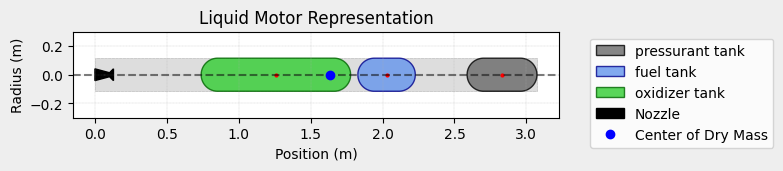

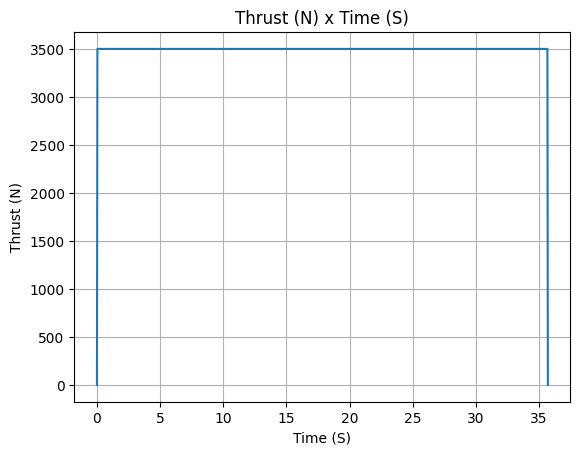

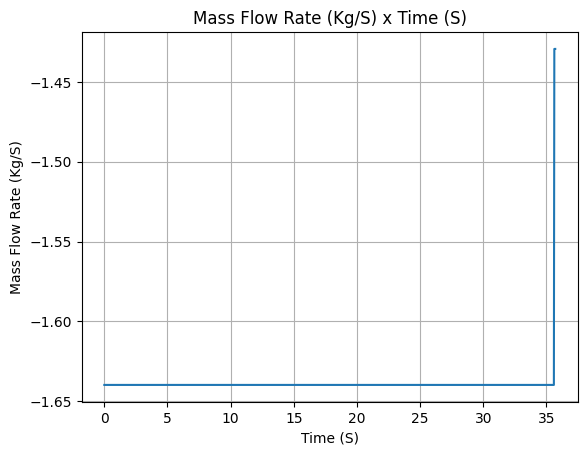

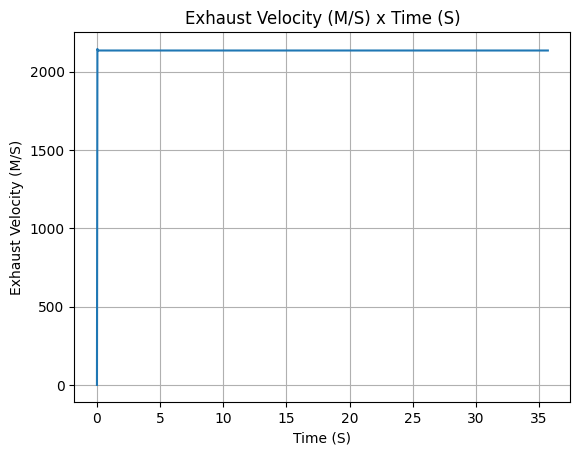

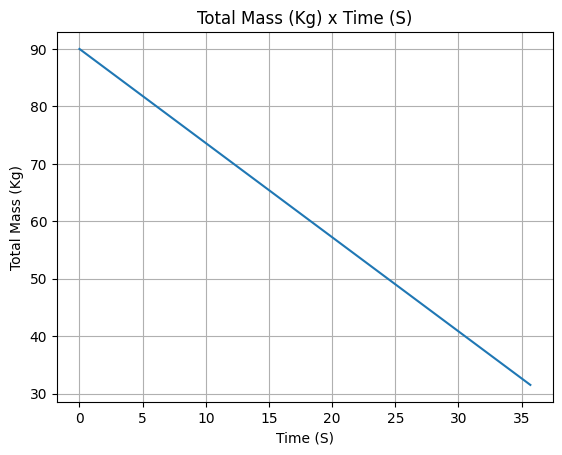

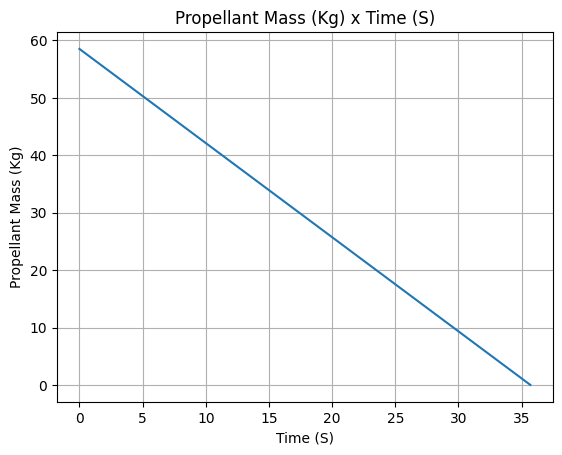

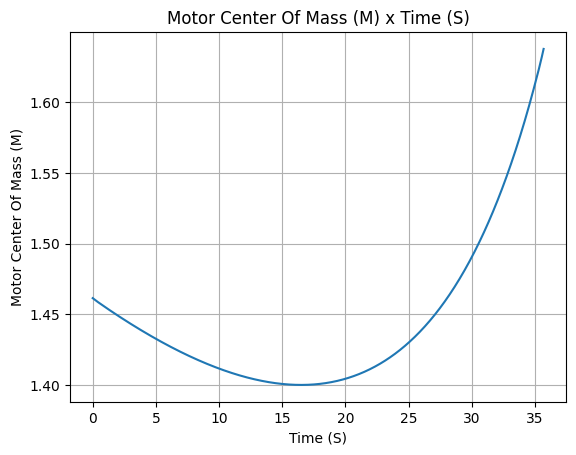

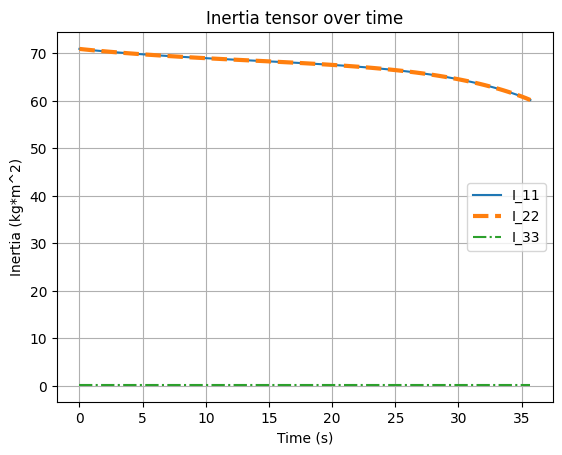

In [18]:
# ------------------------------
# Liquid Motor Usage - ROCKET.PY Library
# ------------------------------
# This script allows for the redesign of the rocket propulsion system in RocketPy, as previously defined.
# See https://docs.rocketpy.org/en/latest/user/motors/motors.html for more information

#-------------------------------
# REQUIREMENTS
# - TORGOS Thurst Curve.
#-------------------------------

#-------------------------------
# RECOMMENDATION
# - To imporve realism, use the ullage tank usage instead of mass_flow_rate_based_tank for the Propellant Tanks (See ROCKET.PY documentation)
#-------------------------------

# Define fluids
oxidizer_liq = Fluid(name="H2O2_l", density=OUT['H2O2_dens'])
oxidizer_gas = Fluid(name="H2O2_g", density=OUT['H2O2_dens'])
fuel_liq = Fluid(name="propane_l", density=OUT['C3H8_dens'])
fuel_gas = Fluid(name="propane_g", density=OUT['C3H8_dens'])
pressure_liq = Fluid(name="pressure_liq", density=OUT['gas_He_dens'])
pressure_gas = Fluid(name="pressure_gas", density=OUT['gas_He_dens'])

# Define tanks geometry
tanks_shape_oxidizer = CylindricalTank(radius = (R_D_tanks*1e-3)/2, height = TANK_H2O2.get('l_t')*1e-3, spherical_caps = True)
tanks_shape_fuel = CylindricalTank(radius = (R_D_tanks*1e-3)/2, height = TANK_C3H8.get('l_t')*1e-3, spherical_caps = True)
tanks_shape_pressure = CylindricalTank(radius = (R_D_tanks*1e-3)/2, height = TANK_He.get('l_t')*1e-3, spherical_caps = True)

# Define tanks
oxidizer_tank = MassFlowRateBasedTank(
    name="oxidizer tank",
    geometry=tanks_shape_oxidizer,
    flux_time= (OUT['PROP_mass'] /MIS['Mass_Flow_Rate_TORGOS']),
    initial_liquid_mass=OUT['H2O2_mass'],
    initial_gas_mass=0,
    liquid_mass_flow_rate_in=0,
    liquid_mass_flow_rate_out= OUT['H2O2_mass']/(OUT['PROP_mass']/MIS['Mass_Flow_Rate_TORGOS']),
    gas_mass_flow_rate_in=0,
    gas_mass_flow_rate_out=0,
    liquid=oxidizer_liq,
    gas=oxidizer_gas,
)

fuel_tank = MassFlowRateBasedTank(
    name="fuel tank",
    geometry=tanks_shape_fuel,
    flux_time=(OUT['PROP_mass'] /MIS['Mass_Flow_Rate_TORGOS'])-0.1,
    initial_liquid_mass=round(OUT['C3H8_mass'],2),
    initial_gas_mass=0,
    liquid_mass_flow_rate_in=0,
    liquid_mass_flow_rate_out= round(OUT['C3H8_mass'],2)/(OUT['PROP_mass']/MIS['Mass_Flow_Rate_TORGOS']),
    gas_mass_flow_rate_in=0,
    gas_mass_flow_rate_out=0,
    liquid=fuel_liq,
    gas=fuel_gas,
)

pressure_tank = MassFlowRateBasedTank(
    name="pressurant tank",
    geometry=tanks_shape_pressure,
    flux_time=(OUT['PROP_mass']/MIS['Mass_Flow_Rate_TORGOS'])-0.1,
    initial_liquid_mass=OUT['gas_He_mass'],                                                         
    initial_gas_mass=0,
    liquid_mass_flow_rate_in=0,
    liquid_mass_flow_rate_out=OUT['gas_He_mass']/(OUT['PROP_mass'] /MIS['Mass_Flow_Rate_TORGOS']),  
    gas_mass_flow_rate_in=0,
    gas_mass_flow_rate_out=0,
    liquid=pressure_liq,
    gas=pressure_gas,
)

liquid_motor = LiquidMotor(
    thrust_source="thrust_curve.csv",
    center_of_dry_mass_position= (R_l_t-Cg_cylinder_tanks_dry)*1e-3,     
    dry_inertia=(I_total[0,0], I_total[1,1], I_total[2,2]),                                           
    dry_mass= (OUT['Mf']- M_Cg_without_motor),                           
    burn_time=OUT['PROP_mass']/MIS['Mass_Flow_Rate_TORGOS'],             
    nozzle_radius=(81.92/2)*1e-3,
    nozzle_position= 0,                             
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)
# Adding tanks to the motor system
liquid_motor.add_tank(pressure_tank, position= (R_l_t - (COORD_tank_He+TANK_He.get('l_t')/2))*1e-3)
liquid_motor.add_tank(fuel_tank, position=(R_l_t -(COORD_tank_C3H8+TANK_C3H8.get('l_t')/2))*1e-3)
liquid_motor.add_tank(oxidizer_tank, position= (R_l_t -(COORD_tank_H2O2+TANK_H2O2.get('l_t')/2))*1e-3)  
liquid_motor.all_info()



Inertia Details

Rocket Mass: 34.884 kg (without motor)
Rocket Dry Mass: 66.378 kg (with unloaded motor)
Rocket Loaded Mass: 124.906 kg
Rocket Structural Mass Ratio: 0.531
Rocket Inertia (with unloaded motor) 11: 126.116 kg*m2
Rocket Inertia (with unloaded motor) 22: 126.081 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.696 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.115 m
Rocket Frontal Area: 0.041548 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.036 m
Rocket Center of Dry Mass - Nozzle Exit: 1.598 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.231 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.108 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 8.756/rad
Tail Lift Coefficien

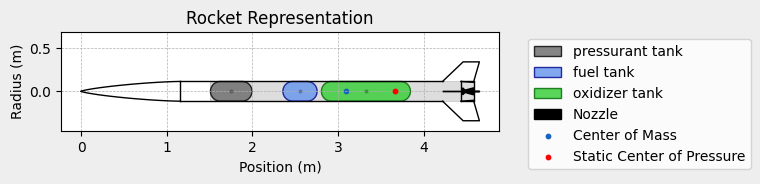


Mass Plots
----------------------------------------


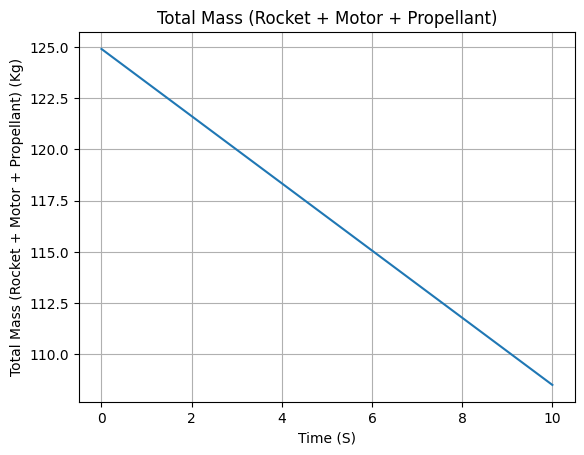

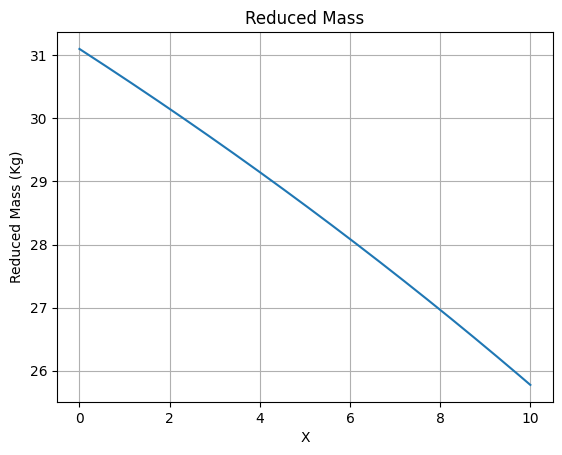


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


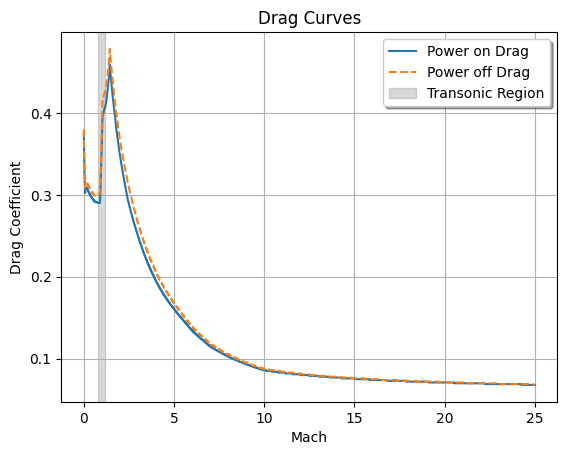


Stability Plots
--------------------


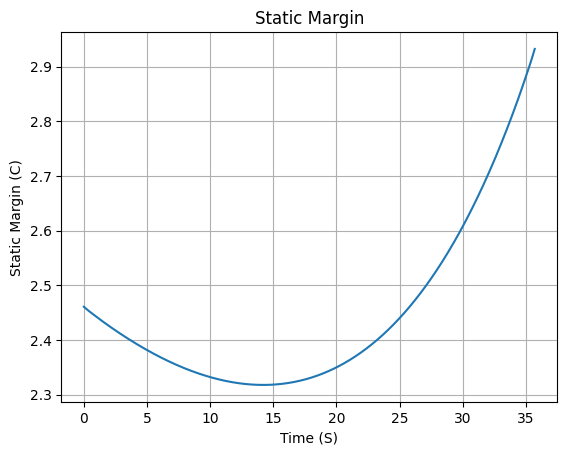

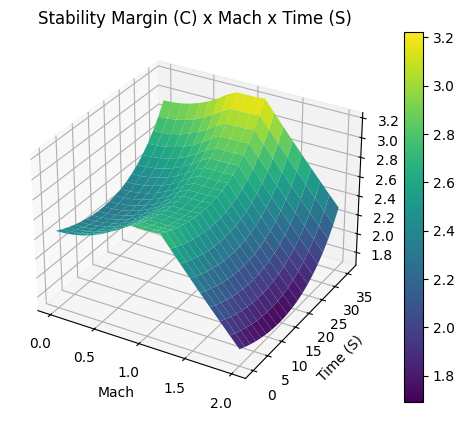


Thrust-to-Weight Plot
----------------------------------------


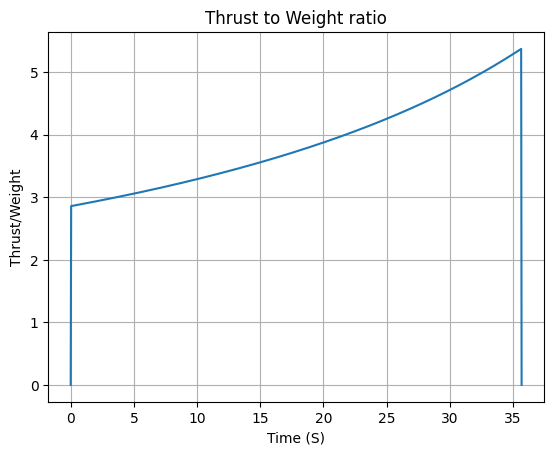

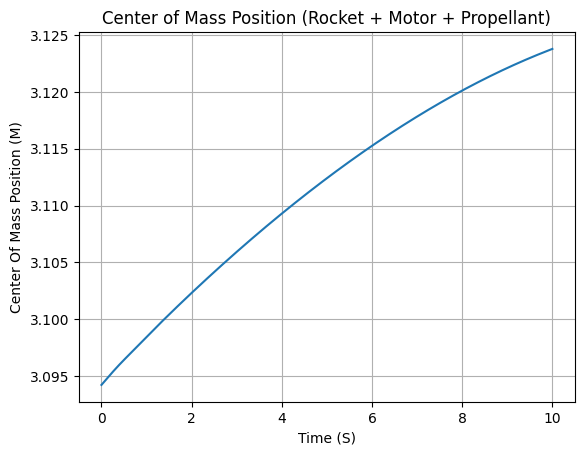

In [19]:
# ------------------------------
# Rocket Motor Usage - ROCKET.PY Library
# ------------------------------
# This script allows for the redesign of the rocket geometry in RocketPy, as previously defined.
# See https://docs.rocketpy.org/en/latest/user/rocket/rocket.html for more information

#-------------------------------
# REQUIREMENTS
# - CD Drag Coefficients Off and On (.csv files)
#-------------------------------

# Designing the Rocket Structure (without the motor)
Mesange_V2_rocket = Rocket(
    radius=(R_D_ext/2)*1e-3,                                                                      
    mass= M_Cg_without_motor,                                                                                                                                          
    inertia=(I_total_without_motor[0,0], I_total_without_motor[1,1], I_total_without_motor[2,2]), 
    power_off_drag="CD_Power_Off_us.csv",
    power_on_drag="CD_Power_On_us.csv",
    center_of_mass_without_motor=Cg_without_motor*1e-3,                                           
    coordinate_system_orientation="nose_to_tail",
)
# Adding the Motor System to the Rocket Structure
Mesange_V2_rocket.add_motor(liquid_motor, position = R_l_t *1e-3)
# Defining the Fairing
nose = Mesange_V2_rocket.add_nose(length=NC_l_nc*1e-3, kind="vonKarman", position=0)
# Defining the fins 
fins = Mesange_V2_rocket.add_trapezoidal_fins(
    n=4,
    root_chord=Root_Chord,
    tip_chord=Tip_Chord,
    span=Span,
    sweep_length = Sweep_Length,
    position=(R_l_t)*1e-3 - Root_Chord,   
    cant_angle=0,
)
# Defing the boat tail
tail = Mesange_V2_rocket.add_tail(
    top_radius=(R_D_ext/2)*1e-3, bottom_radius=(BT_D/2)*1e-3, length=BT_l*1e-3, position= (R_l_t - BT_l)*1e-3
)

Mesange_V2_rocket.all_info() # Plots all results
Mesange_V2_rocket.center_of_mass() 

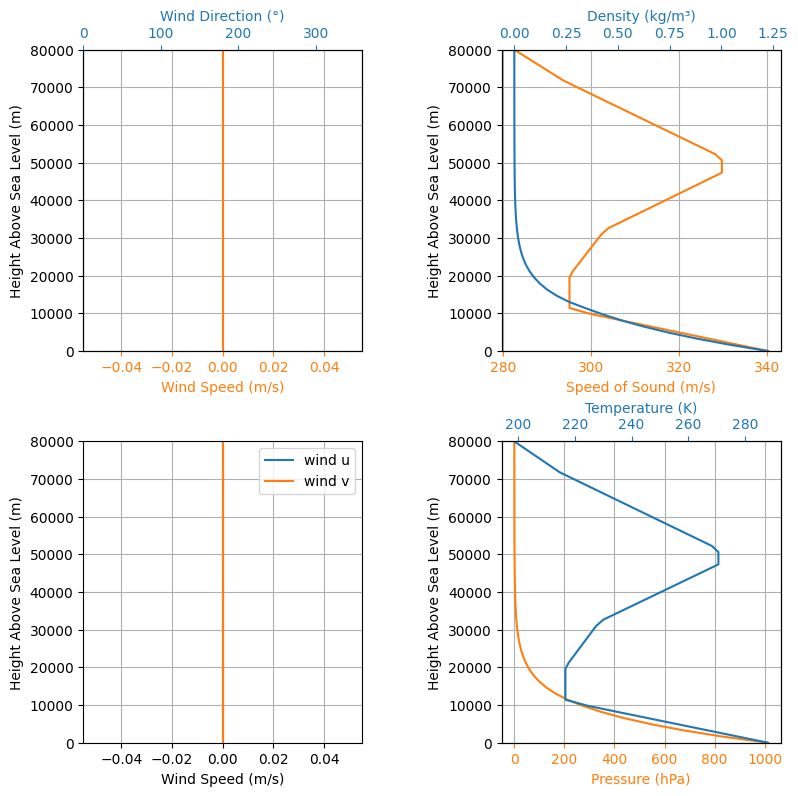

In [20]:
# ------------------------------
# Environment - ROCKET.PY Library
# ------------------------------
# This script allows for the environment in RocketPy.
# See https://docs.rocketpy.org/en/latest/user/environment.html for more information

env = Environment() # already initializes the International Standard Atmosphere

env.plots.atmospheric_model()

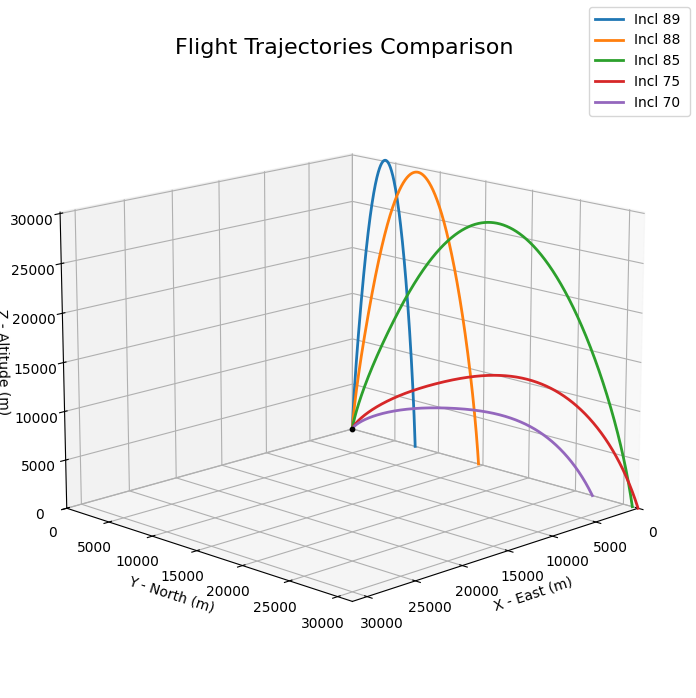

c:\LOCAL\.venv\Lib\site-packages\rocketpy\plots\plot_helpers.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


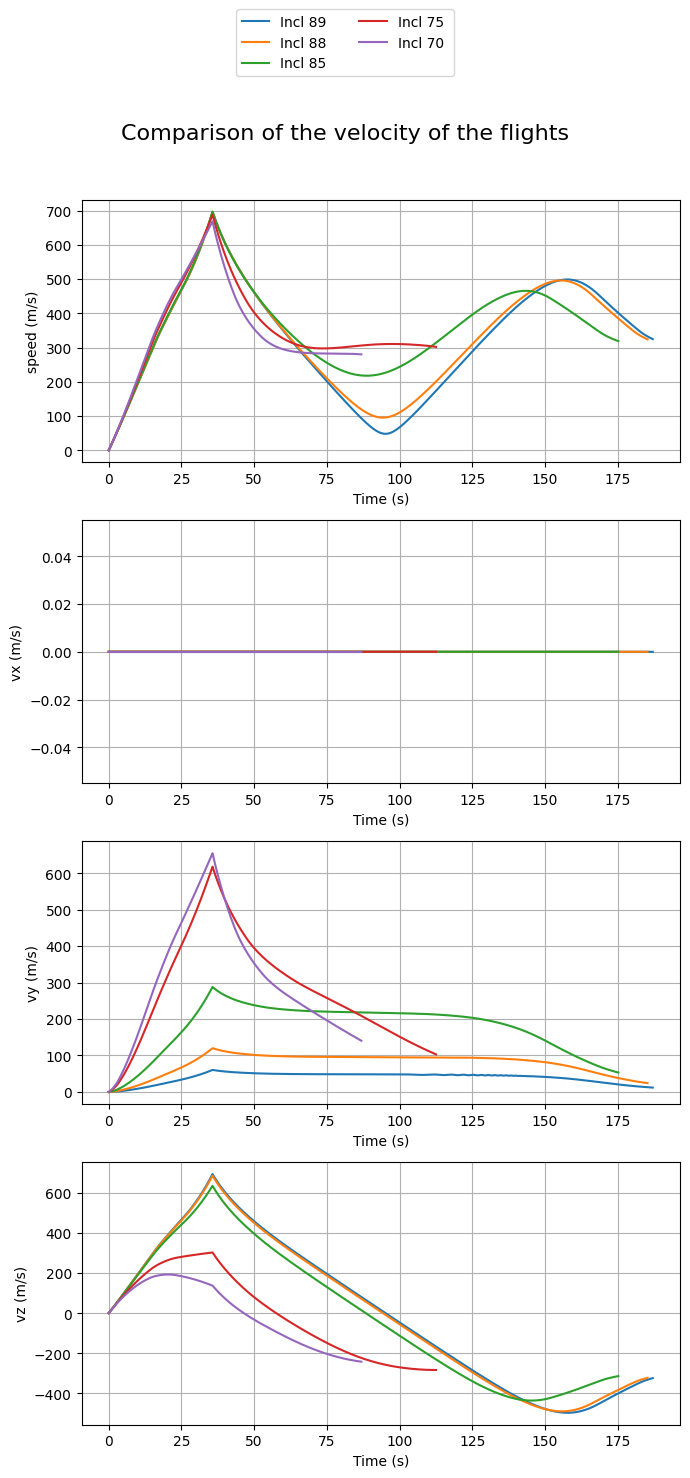

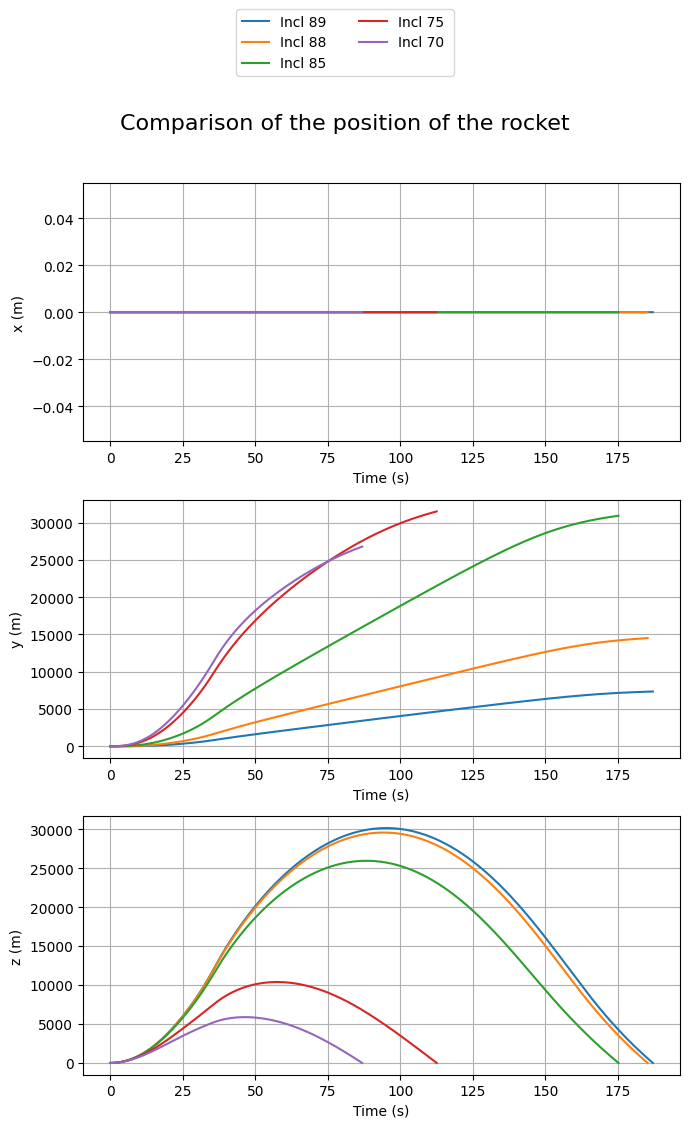

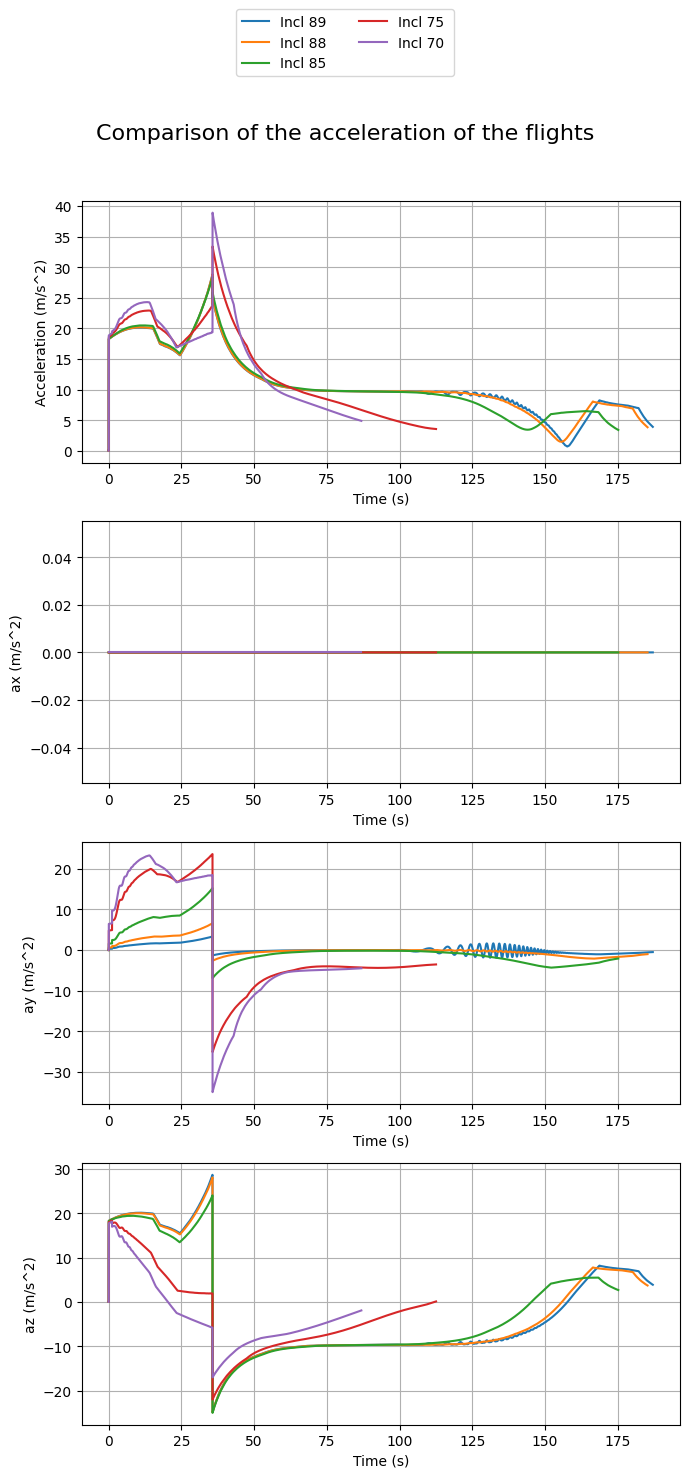

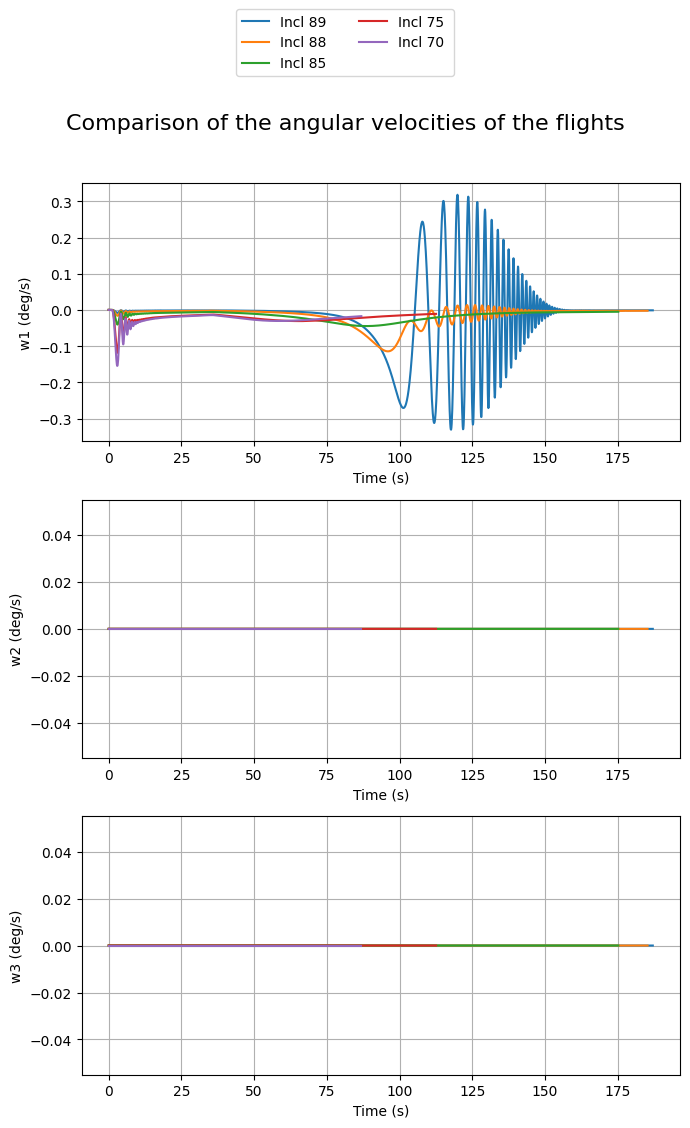

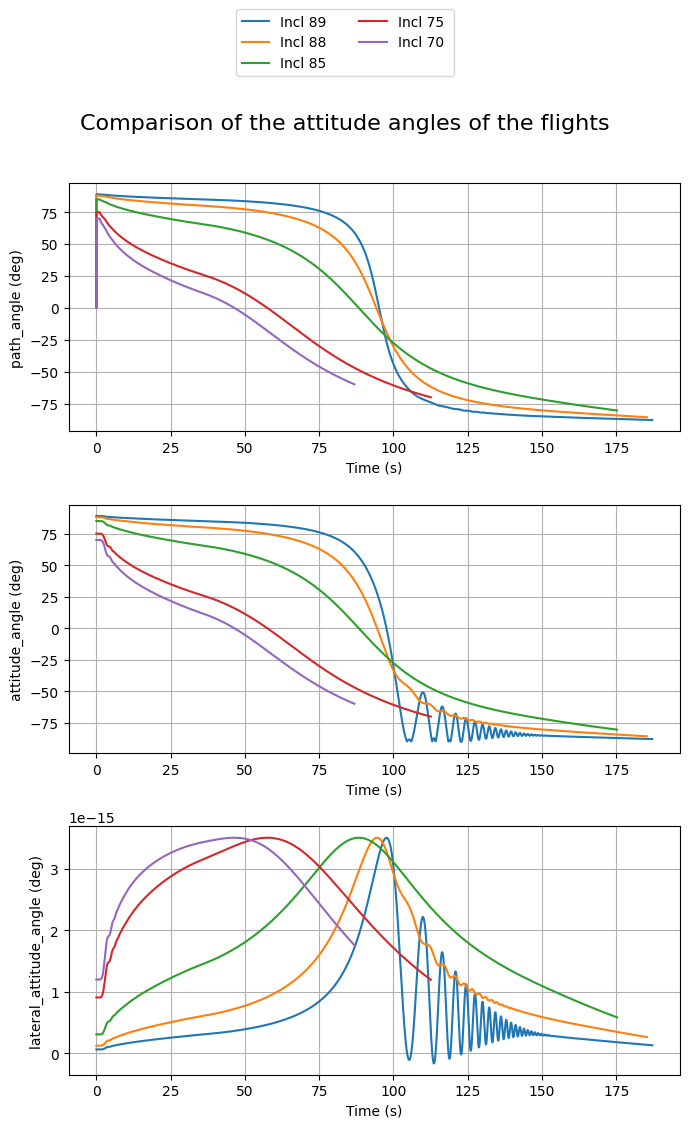

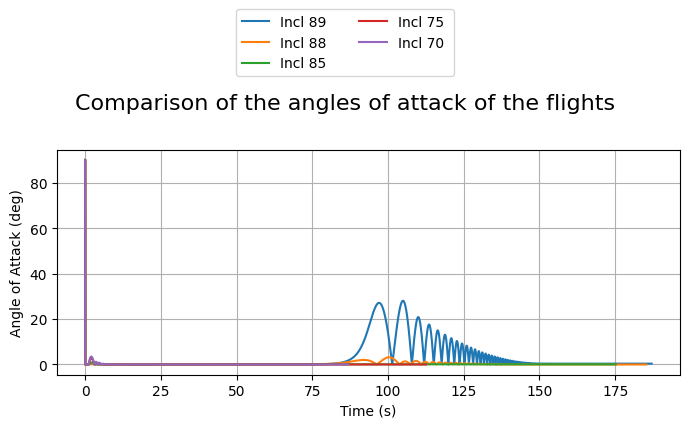

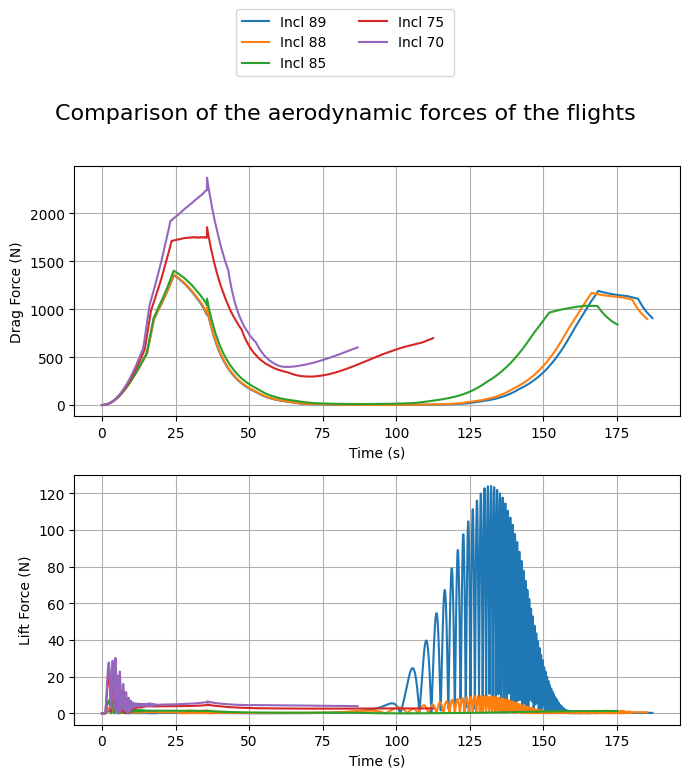

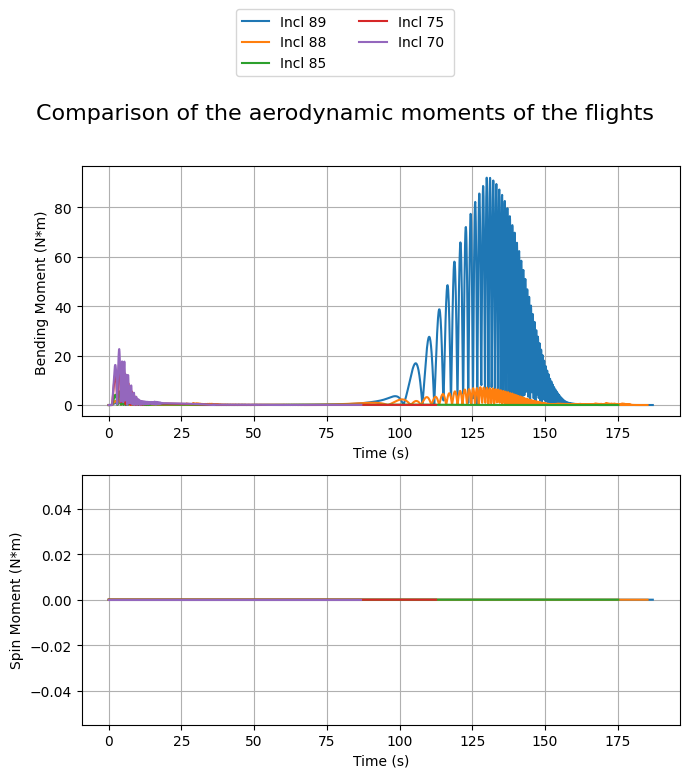

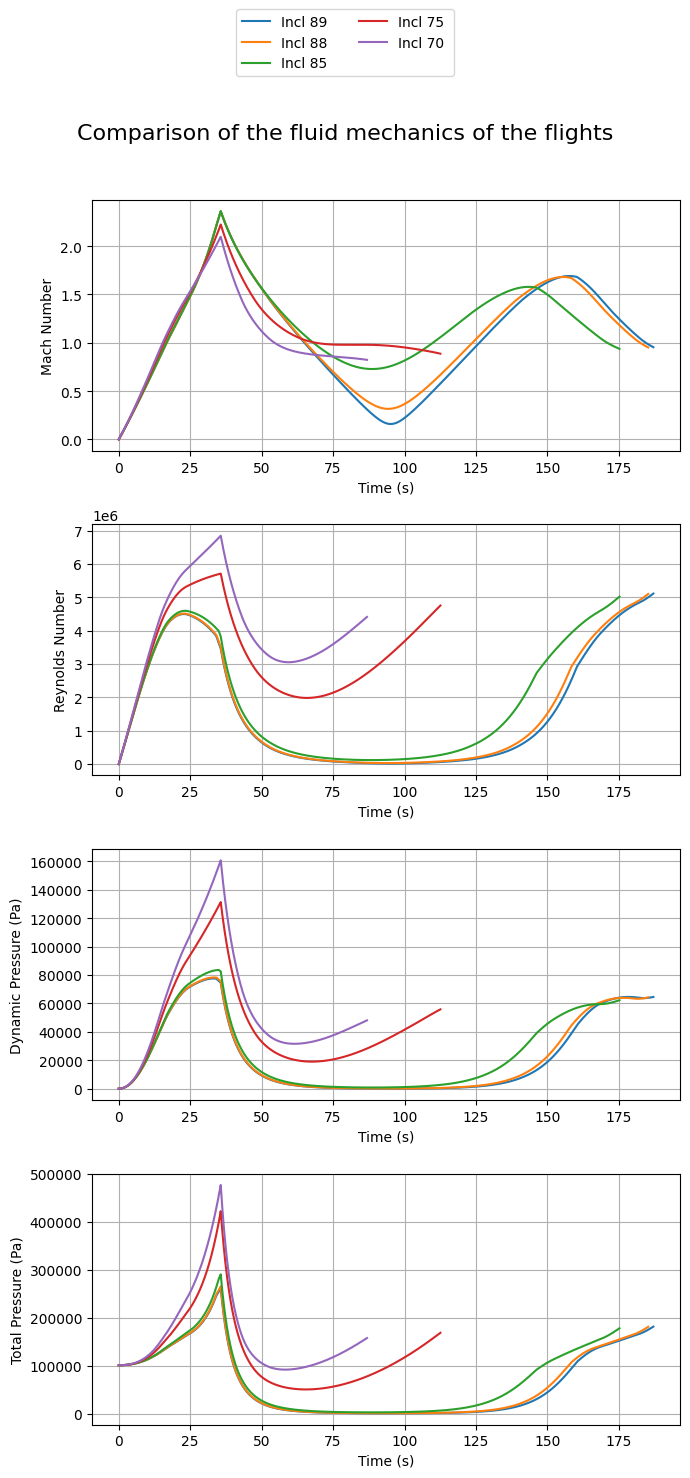

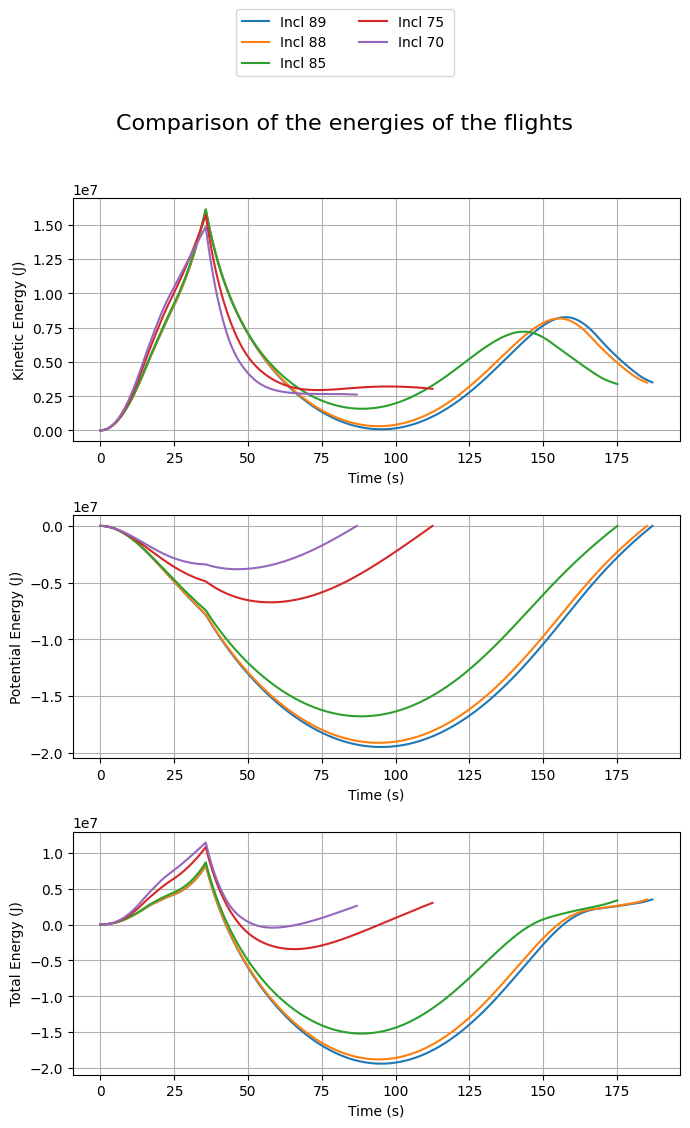

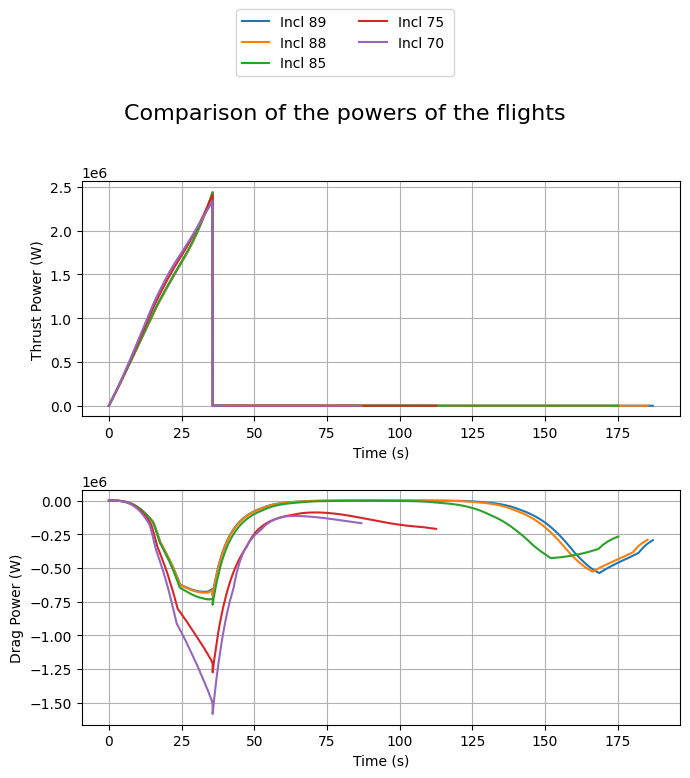

In [ ]:
# ------------------------------
# Flight Model - ROCKET.PY Library
# ------------------------------
# This script allows to calculate the flight regarding .
# See https://docs.rocketpy.org/en/latest/user/environment.html for more information

from rocketpy.plots.compare import CompareFlights
inclinations = [89,88,85,75,70]
flights = []

for inclination in inclinations:
    flight = Flight( 
    rocket=Mesange_V2_rocket,
    environment=env,
    rail_length=12,             # [m]
    inclination=inclination,    # [°]
    heading=0,                  # [°]
    name=f"Incl {inclination} ",
    max_time_step=0.1,
    terminate_on_apogee=False,
    )
    flights.append(flight)

# Flight Comparaison 
comparison = CompareFlights(flights)            
comparison.trajectories_3d(legend=True)
comparison.velocities()
comparison.positions()
comparison.accelerations()
comparison.angular_velocities()
comparison.attitude_angles()
comparison.angles_of_attack()
comparison.aerodynamic_forces()
comparison.aerodynamic_moments()
comparison.fluid_mechanics()
comparison.energies()
comparison.powers()

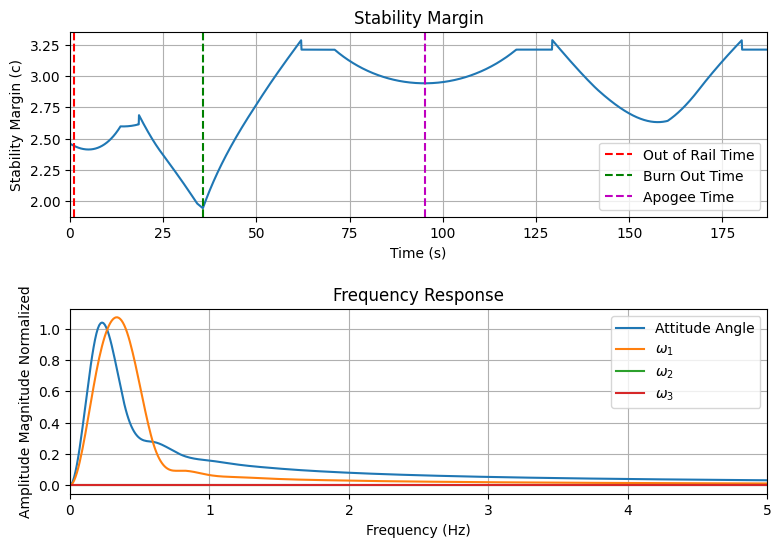

In [ ]:
# ------------------------------
# Flight Model - ROCKET.PY Library
# ------------------------------
# This script allows to calculate the stability margin. An inclination angle must be designated by the user
# See https://docs.rocketpy.org/en/latest/user/environment.html for more information

flight_stability_check = Flight( 
rocket=Mesange_V2_rocket,
environment=env,
rail_length=12,
inclination=89,
heading=0,
max_time_step=0.1,
terminate_on_apogee=False,
)
flight_stability_check.plots.stability_and_control_data()

# Export the trajectory data in .csv
flight_stability_check.export_data("trajectory_89.csv", "x", "y", "z", time_step=0.1)
